In [24]:
from pathlib import Path

from pyref.io import read_experiment


In [25]:
data_path = Path("/Volumes/DATA/Collins/2026June/")

data_path.exists()

True

In [26]:
sample_x = 27.95
sample_y = 27.89
sample_z = 0.05

In [27]:
import numpy as np
import pandas as pd

energy = np.arange(283, 289.1, .1)[:-1]
z_direct_offset = -2

i0 = pd.DataFrame(
    {
        "Sample X": [sample_x] * len(energy),
        "Sample Y": [sample_y] * len(energy),
        "Sample Z": [sample_z + z_direct_offset] * len(energy),
        "Sample Theta": [0] * len(energy),
        "CCD Theta": [0] * len(energy),
        "Beamline Energy": energy,
        "": [0.002] * len(energy),
    }
)
i0

,Sample X,Sample Y,Sample Z,Sample Theta,CCD Theta,Beamline Energy,
0,27.95,27.89,-1.95,0,0,283.0,0.002
1,27.95,27.89,-1.95,0,0,283.1,0.002
2,27.95,27.89,-1.95,0,0,283.2,0.002
3,27.95,27.89,-1.95,0,0,283.3,0.002
4,27.95,27.89,-1.95,0,0,283.4,0.002
...,...,...,...,...,...,...,...
56,27.95,27.89,-1.95,0,0,288.6,0.002
57,27.95,27.89,-1.95,0,0,288.7,0.002
58,27.95,27.89,-1.95,0,0,288.8,0.002
59,27.95,27.89,-1.95,0,0,288.9,0.002


In [28]:
sample_theta = [13.1, 13.2, 13.3]
exposure_times = [2, 2, 2]

dfs = []
for i, theta in enumerate(sample_theta):
    dfs.append(i0.copy())
    dfs[-1]["Sample Z"] = [sample_z] * len(energy)
    dfs[-1]["Sample Theta"] = [theta] * len(energy)
    dfs[-1]["CCD Theta"] = [2*theta] * len(energy)
    dfs[-1][""] = [exposure_times[i]] * len(energy)

df_13 = pd.concat(dfs)
# dsort by sample theta
df_13 = df_13.sort_values(["Beamline Energy", "Sample Theta"])
df_13

,Sample X,Sample Y,Sample Z,Sample Theta,CCD Theta,Beamline Energy,
0,27.95,27.89,0.05,13.1,26.2,283.0,2
0,27.95,27.89,0.05,13.2,26.4,283.0,2
0,27.95,27.89,0.05,13.3,26.6,283.0,2
1,27.95,27.89,0.05,13.1,26.2,283.1,2
1,27.95,27.89,0.05,13.2,26.4,283.1,2
...,...,...,...,...,...,...,...
59,27.95,27.89,0.05,13.2,26.4,288.9,2
59,27.95,27.89,0.05,13.3,26.6,288.9,2
60,27.95,27.89,0.05,13.1,26.2,289.0,2
60,27.95,27.89,0.05,13.2,26.4,289.0,2


In [29]:
scan_df = pd.concat([i0, df_13])
scan_df

,Sample X,Sample Y,Sample Z,Sample Theta,CCD Theta,Beamline Energy,
0,27.95,27.89,-1.95,0.0,0.0,283.0,0.002
1,27.95,27.89,-1.95,0.0,0.0,283.1,0.002
2,27.95,27.89,-1.95,0.0,0.0,283.2,0.002
3,27.95,27.89,-1.95,0.0,0.0,283.3,0.002
4,27.95,27.89,-1.95,0.0,0.0,283.4,0.002
...,...,...,...,...,...,...,...
59,27.95,27.89,0.05,13.2,26.4,288.9,2.000
59,27.95,27.89,0.05,13.3,26.6,288.9,2.000
60,27.95,27.89,0.05,13.1,26.2,289.0,2.000
60,27.95,27.89,0.05,13.2,26.4,289.0,2.000


In [30]:
from time import time

time_est = (0.3 + 1) * len(scan_df) + scan_df[""].sum()  # total seconds
time_est_hours = time_est / 3600  # convert to hours

print(f"Estimated time: {time_est_hours:.2f} hours")

Estimated time: 0.19 hours


In [31]:
scan_df.to_csv("/Volumes/DATA/Collins/2026June/.macro/znpc_fixed_angle_p.txt", index=False, sep="\t")

In [49]:
from astropy.io import fits

data = "/Volumes/DATA/Collins/2026June/2026 06 15/CCD Scan 89623/Axis Photonique"

In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
from astropy.io import fits
from pyref.io import scan_experiment

HEADER_KEYS = [
    "DATE",
    "EXPOSURE",
    "Beamline Energy",
    "Sample Theta",
    "CCD Theta",
    "Sample X",
    "Sample Y",
    "Sample Z",
    "Ai 3 Izero",
    "Photodiode",
    "TEY signal",
]


def load_fits_image(file_path: str) -> np.ndarray:
    """Load the detector image array from the last HDU of a FITS file."""
    with fits.open(file_path) as hdul:
        return np.asarray(hdul[-1].data)


fits_root = Path(data)
fits_paths = sorted(fits_root.rglob("*.fits"))

fits_df = scan_experiment(fits_paths, header_items=HEADER_KEYS).collect().to_pandas()
fits_df["image"] = [load_fits_image(p) for p in fits_df["file_path"]]

dataframe filtered
dataframe filtered
dataframe filtered
dataframe filtered


In [51]:
from dataclasses import dataclass

from scipy.ndimage import median_filter
from scipy.optimize import curve_fit

MARGIN = 10
EDGE_STRIP = 10
BG_MEDIAN_SIZE = 20
PEAK_MEDIAN_SIZE = 5
INTEGRATION_HALF = 5
MIN_BG_BOX_GAP = 15
BOX_PIXELS = (2 * INTEGRATION_HALF) ** 2


@dataclass
class GaussianBeamFit:
    amplitude: float
    center_row: float
    center_col: float
    sigma_row: float
    sigma_col: float
    background: float


@dataclass
class SpecularReflectivity:
    beam_region: np.ndarray
    background_region: np.ndarray
    beam_intensity: float
    background_intensity: float
    beam_sigma: float
    background_sigma: float
    signal: float
    signal_sigma: float
    center_row: float
    center_col: float
    bg_constant: float
    gaussian_amplitude: float
    fit: GaussianBeamFit


def _extract_region(
    arr: np.ndarray,
    row: int,
    col: int,
    half: int = INTEGRATION_HALF,
) -> np.ndarray:
    return np.asarray(
        arr[row - half : row + half, col - half : col + half],
        dtype=np.float64,
    )


def _crop_image(img: np.ndarray) -> np.ndarray:
    return np.asarray(img[MARGIN:-MARGIN, MARGIN:-MARGIN], dtype=np.float64)


def _gaussian2d_constant(
    coords: tuple[np.ndarray, np.ndarray],
    amplitude: float,
    center_row: float,
    center_col: float,
    sigma_row: float,
    sigma_col: float,
    background: float,
) -> np.ndarray:
    row, col = coords
    row_term = ((row - center_row) / sigma_row) ** 2
    col_term = ((col - center_col) / sigma_col) ** 2
    return amplitude * np.exp(-0.5 * (row_term + col_term)) + background


def _fit_gaussian_background(image: np.ndarray) -> GaussianBeamFit:
    """
    Fit a 2D Gaussian plus constant offset to a detector image.

    The fitted center locates the beam; the constant term estimates the
    per-pixel background below the spot.
    """
    ny, nx = image.shape
    peak_row, peak_col = np.unravel_index(int(np.argmax(image)), image.shape)
    background0 = float(np.median(image))
    amplitude0 = max(float(image[peak_row, peak_col]) - background0, 1.0)
    p0 = (amplitude0, float(peak_row), float(peak_col), 8.0, 8.0, background0)
    lower = (0.0, 0.0, 0.0, 0.5, 0.5, -np.inf)
    upper = (np.inf, float(ny - 1), float(nx - 1), float(ny), float(nx), np.inf)
    row_grid, col_grid = np.mgrid[0:ny, 0:nx]
    popt, _ = curve_fit(
        _gaussian2d_constant,
        (row_grid.ravel(), col_grid.ravel()),
        image.ravel(),
        p0=p0,
        bounds=(lower, upper),
        maxfev=20_000,
    )
    return GaussianBeamFit(
        amplitude=float(popt[0]),
        center_row=float(popt[1]),
        center_col=float(popt[2]),
        sigma_row=float(popt[3]),
        sigma_col=float(popt[4]),
        background=float(popt[5]),
    )


def _detector_corrected(cropped: np.ndarray) -> np.ndarray:
    """
    Apply periodic 20x20 median smoothing, then subtract edge backgrounds.

    Row and column backgrounds use the larger of opposing 10-pixel edge-strip
    sums on the original cropped image, applied after median smoothing.
    """
    smoothed = median_filter(cropped, size=BG_MEDIAN_SIZE, mode="wrap")
    left_row = cropped[:, :EDGE_STRIP].sum(axis=1)
    right_row = cropped[:, -EDGE_STRIP:].sum(axis=1)
    row_bg = np.maximum(left_row, right_row)[:, np.newaxis] / EDGE_STRIP

    top_col = cropped[:EDGE_STRIP, :].sum(axis=0)
    bottom_col = cropped[-EDGE_STRIP:, :].sum(axis=0)
    col_bg = np.maximum(top_col, bottom_col)[np.newaxis, :] / EDGE_STRIP

    return smoothed - row_bg - col_bg


def _background_column(peak_col: int, n_cols: int) -> int:
    """
    Column index for the reflected background box with a minimum edge gap from the beam.

    Starts from column reflection about the image center; if that places the boxes
    too close, shifts the background box farther along the outward horizontal axis.
    """
    half = INTEGRATION_HALF
    col_min = half
    col_max = n_cols - half - 1
    min_center_sep = 2 * half + MIN_BG_BOX_GAP
    reflected = (n_cols - 1) - peak_col
    if abs(reflected - peak_col) >= min_center_sep:
        bg_col = reflected
    elif reflected <= peak_col:
        bg_col = peak_col - min_center_sep
    else:
        bg_col = peak_col + min_center_sep
    return int(np.clip(bg_col, col_min, col_max))


def _locate_specular_regions(
    img: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, GaussianBeamFit, int, int, int]:
    """
    Return crops, Gaussian fit, and integer integration indices.

    Beam center comes from a 2D Gaussian plus constant fit on the corrected
    image. Integration boxes are centered on the rounded Gaussian center on
    the raw crop; the fit constant sets the background level.
    """
    cropped = _crop_image(img)
    corrected = _detector_corrected(cropped)
    filtered = median_filter(corrected, size=PEAK_MEDIAN_SIZE, mode="wrap")
    try:
        fit = _fit_gaussian_background(corrected)
    except (RuntimeError, ValueError):
        peak_row, peak_col = np.unravel_index(int(np.argmax(filtered)), filtered.shape)
        fit = GaussianBeamFit(
            amplitude=float(filtered[peak_row, peak_col]),
            center_row=float(peak_row),
            center_col=float(peak_col),
            sigma_row=5.0,
            sigma_col=5.0,
            background=float(np.median(corrected)),
        )
    peak_row = int(np.clip(round(fit.center_row), INTEGRATION_HALF, cropped.shape[0] - INTEGRATION_HALF - 1))
    peak_col = int(np.clip(round(fit.center_col), INTEGRATION_HALF, cropped.shape[1] - INTEGRATION_HALF - 1))
    bg_col = _background_column(peak_col, cropped.shape[1])
    return cropped, corrected, filtered, fit, peak_row, peak_col, bg_col


def spec_refl(img: np.ndarray) -> SpecularReflectivity:
    """
    Estimate specular reflectivity from a 2D detector image.

    Crop a 10-pixel border, subtract row/column edge backgrounds, fit a 2D
    Gaussian plus constant on the corrected image for sub-pixel beam center and
    background level, then integrate 10x10 regions on the raw crop above the
    fitted constant and propagate Poisson counting errors through the ratio.

    Parameters
    ----------
    img : ndarray
        Raw detector image.

    Returns
    -------
    SpecularReflectivity
        Beam and background 10x10 regions, integrated intensities, their
        sqrt(N) uncertainties, and the background-corrected ratio with error.

    Notes
    -----
    Returns ``signal`` and ``signal_sigma`` as NaN when the background sum is
    not positive. Relative Poisson errors use zero beam contribution when the
    beam sum is zero.
    """
    cropped, _corrected, _filtered, fit, peak_row, peak_col, bg_col = _locate_specular_regions(
        img
    )

    beam_region = _extract_region(cropped, peak_row, peak_col)
    background_region = _extract_region(cropped, peak_row, bg_col)
    bg_floor = max(fit.background, 0.0) * BOX_PIXELS

    beam_intensity = max(float(beam_region.sum()) - bg_floor, 0.0)
    background_intensity = max(float(background_region.sum()) - bg_floor, 0.0)
    beam_sigma = float(np.sqrt(max(beam_intensity, 0.0)))
    background_sigma = float(np.sqrt(max(background_intensity, 0.0)))

    if background_intensity <= 0:
        signal = np.nan
        signal_sigma = np.nan
    else:
        signal = beam_intensity / background_intensity
        rel_beam = beam_sigma / beam_intensity if beam_intensity > 0 else 0.0
        rel_bg = background_sigma / background_intensity
        signal_sigma = float(signal * np.hypot(rel_beam, rel_bg))

    return SpecularReflectivity(
        beam_region=beam_region,
        background_region=background_region,
        beam_intensity=beam_intensity,
        background_intensity=background_intensity,
        beam_sigma=beam_sigma,
        background_sigma=background_sigma,
        signal=signal,
        signal_sigma=signal_sigma,
        center_row=fit.center_row,
        center_col=fit.center_col,
        bg_constant=fit.background,
        gaussian_amplitude=fit.amplitude,
        fit=fit,
    )


In [52]:
import matplotlib.pyplot as plt

spec = fits_df["image"].map(spec_refl)


In [42]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Rectangle


def _groups_by_theta(df: pd.DataFrame) -> dict[float, pd.DataFrame]:
    return {
        float(theta): group.reset_index(drop=True)
        for theta, group in df.groupby("Sample Theta", sort=True)
    }


def _draw_region_boxes(
    ax: plt.Axes,
    peak_row: int,
    peak_col: int,
    bg_col: int,
    fit: GaussianBeamFit,
) -> None:
    box = 2 * INTEGRATION_HALF
    for col, color, label in (
        (peak_col, "cyan", "beam box"),
        (bg_col, "orange", "bg box"),
    ):
        ax.add_patch(
            Rectangle(
                (col - INTEGRATION_HALF, peak_row - INTEGRATION_HALF),
                box,
                box,
                fill=False,
                edgecolor=color,
                linewidth=2,
                label=label,
            )
        )
    ax.plot(
        fit.center_col,
        fit.center_row,
        "+",
        color="white",
        markersize=12,
        markeredgewidth=2,
        label="Gaussian center",
    )


def _mute_profile_axes(ax: plt.Axes) -> None:
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)


def _plot_image_with_profiles(
    fig: plt.Figure,
    outer_gs,
    data: np.ndarray,
    panel_title: str,
    peak_row: int,
    peak_col: int,
    bg_col: int,
    fit: GaussianBeamFit,
) -> None:
    inner = outer_gs.subgridspec(
        2,
        2,
        width_ratios=[0.1, 1.0],
        height_ratios=[0.1, 1.0],
        wspace=0.02,
        hspace=0.02,
    )
    ax_img = fig.add_subplot(inner[1, 1])
    ax_col = fig.add_subplot(inner[0, 1], sharex=ax_img)
    ax_row = fig.add_subplot(inner[1, 0], sharey=ax_img)

    row_sum = data.sum(axis=1)
    col_sum = data.sum(axis=0)
    rows = np.arange(data.shape[0])
    cols = np.arange(data.shape[1])

    ax_img.imshow(data, cmap="viridis", origin="upper", aspect="auto")
    _draw_region_boxes(ax_img, peak_row, peak_col, bg_col, fit)
    ax_img.set_xticks([])
    ax_img.set_yticks([])

    ax_col.plot(cols, col_sum, color="0.85", linewidth=0.9)
    ax_row.plot(row_sum, rows, color="0.85", linewidth=0.9)

    row_min = float(row_sum.min()) if row_sum.size else 0.0
    row_max = float(row_sum.max()) if row_sum.size else 1.0
    col_min = float(col_sum.min()) if col_sum.size else 0.0
    col_max = float(col_sum.max()) if col_sum.size else 1.0
    row_pad = 0.05 * max(row_max - row_min, 1.0)
    col_pad = 0.05 * max(col_max - col_min, 1.0)
    ax_row.set_xlim(row_max + row_pad, row_min - row_pad)
    ax_col.set_ylim(col_min - col_pad, col_max + col_pad)

    ax_col.axvline(fit.center_col, color="white", linestyle="--", linewidth=0.9, alpha=0.9)
    ax_row.axhline(fit.center_row, color="white", linestyle="--", linewidth=0.9, alpha=0.9)

    _mute_profile_axes(ax_col)
    _mute_profile_axes(ax_row)
    ax_col.set_title(panel_title, fontsize=10, pad=2)

def _plot_region_preview(theta: float, frame_idx: int) -> None:
    group = _preview_groups[theta]
    frame_idx = int(np.clip(frame_idx, 0, len(group) - 1))
    row = group.iloc[frame_idx]
    img = row["image"]
    result = row["spec_result"]
    cropped, corrected, filtered, fit, peak_row, peak_col, bg_col = _locate_specular_regions(
        img
    )

    energy = row["Beamline Energy"]
    fig = plt.figure(figsize=(14, 5.2), layout="constrained")
    outer = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.12)
    _plot_image_with_profiles(
        fig, outer[0], cropped, "Original (integration)", peak_row, peak_col, bg_col, fit
    )
    _plot_image_with_profiles(
        fig,
        outer[1],
        corrected,
        "Corrected (Gaussian fit)",
        peak_row,
        peak_col,
        bg_col,
        fit,
    )

    handles, labels = fig.axes[-1].get_legend_handles_labels()
    fig.axes[-1].legend(handles, labels, loc="upper right", fontsize=8)
    fig.suptitle(
        f"theta = {theta:g} deg  |  E = {energy:.2f} eV  |  {row['file_name']}\n"
        f"R = {result.signal:.4g} +/- {result.signal_sigma:.4g}  |  "
        f"beam = {result.beam_intensity:.0f}  |  bg box = {result.background_intensity:.0f}  |  "
        f"B = {result.bg_constant:.2f}  |  A = {result.gaussian_amplitude:.1f}",
        fontsize=11,
    )
    plt.show()
    plt.close(fig)


_preview_df = fits_df.assign(spec_result=spec)
_preview_groups = _groups_by_theta(_preview_df)

_theta_dropdown = widgets.Dropdown(
    options=[(f"theta = {theta:g} deg", theta) for theta in _preview_groups],
    description="Angle",
    layout=widgets.Layout(width="280px"),
)

_frame_slider = widgets.IntSlider(
    description="Frame",
    min=0,
    max=0,
    value=0,
    continuous_update=False,
    readout=True,
    layout=widgets.Layout(width="480px"),
)


def _sync_frame_slider(*_) -> None:
    group = _preview_groups[_theta_dropdown.value]
    n_frames = len(group)
    _frame_slider.max = max(n_frames - 1, 0)
    _frame_slider.value = min(_frame_slider.value, _frame_slider.max)
    if n_frames:
        energy = group.iloc[_frame_slider.value]["Beamline Energy"]
        _frame_slider.description = f"Frame (E={energy:.1f} eV)"


_theta_dropdown.observe(_sync_frame_slider, names="value")
_frame_slider.observe(_sync_frame_slider, names="value")

_region_out = widgets.interactive_output(
    _plot_region_preview,
    {"theta": _theta_dropdown, "frame_idx": _frame_slider},
)

_sync_frame_slider()
display(widgets.VBox([_theta_dropdown, _frame_slider, _region_out]))

In [45]:
fits_df.columns

Index(['DATE', 'EXPOSURE', 'Beamline Energy', 'Sample Theta', 'CCD Theta',
       'Sample X', 'Sample Y', 'Sample Z', 'IZERO', 'Photodiode', 'TEY signal',
       'file_name', 'sample_name', 'tag', 'scan_number', 'frame_number',
       'file_path', 'data_offset', 'naxis1', 'naxis2', 'bitpix', 'data_size',
       'bzero', 'Lambda', 'Q', 'image', 'reflectivity', 'reflectivity_err',
       'intensity', 'intensity_err'],
      dtype='str')

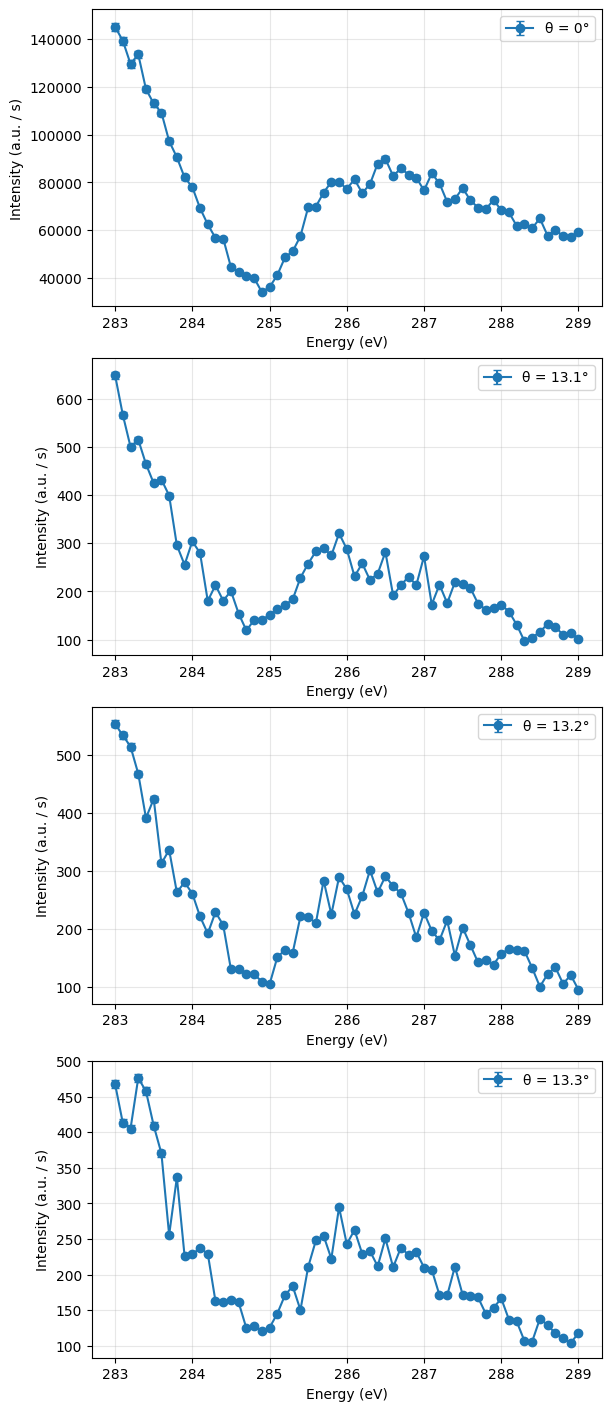

In [48]:

fits_df = fits_df.assign(
    reflectivity=spec.map(lambda r: r.signal),
    reflectivity_err=spec.map(lambda r: r.signal_sigma),
)
fits_df["intensity"] = fits_df["reflectivity"] / fits_df["EXPOSURE"]
fits_df["intensity_err"] = fits_df["reflectivity_err"] / fits_df["EXPOSURE"]

plot_df = (
    fits_df.dropna(subset=["intensity"])
    .sort_values(["Sample Theta", "Beamline Energy"])
    .reset_index(drop=True)
)
theta_groups = list(plot_df.groupby("Sample Theta", sort=True))
n_panels = len(theta_groups)

fig, _ = plt.subplots(
    nrows=n_panels,
    figsize=(6, 3.5 * n_panels),
    layout="constrained",
)


for ax_i, (theta, group) in zip(fig.axes, theta_groups):
    # if theta != 0:
    #     # Divide by the theta == 0 data
    #     izero_group = plot_df[plot_df["Sample Theta"] == 0]
    #     group["intensity"] = group["intensity"] / izero_group["intensity"]
    #     group["intensity_err"] = group["intensity_err"] / izero_group["intensity"]
    ax_i.errorbar(
        group["Beamline Energy"],
        group["intensity"],
        yerr=group["intensity_err"],
        fmt="o-",
        capsize=3,
        label=f"θ = {theta:g}°",
    )
    ax_i.set_xlabel("Energy (eV)")
    ax_i.set_ylabel("Intensity (a.u. / s)")
    ax_i.legend()
    ax_i.grid(True, alpha=0.3)

plt.show()

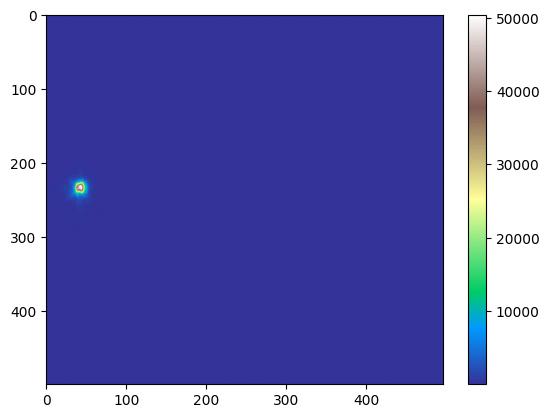

In [87]:
test_img = "/Volumes/DATA/Collins/2026May/2026 05 17/CCD Scan 89286/Axis Photonique/znpc_89286-00001.fits"
test_img = "/Volumes/DATA/Collins/2026May/2026 05 17/CCD Scan 89287/Axis Photonique/znpc_89287-00001.fits"
# REad the image from this
img = load_fits_image(test_img)
# Plot the image
plt.imshow(img, cmap="terrain", origin="upper", aspect="auto")
plt.colorbar()
plt.show()